<a href="https://colab.research.google.com/github/rufinaagilmanova-cogsup/cogsup-prog/blob/main/Gilmanova_R_LLM_lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CELL 1 — Installs + Imports

In [ ]:
!pip install datasets

# imports
import os
import json
import pickle
import random
import math
import time
import re
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from google.colab import drive

#mount drive
drive.mount('/content/drive')
CACHE_DIR = '/content/drive/MyDrive/gpt_poetry_cache'
os.makedirs(CACHE_DIR, exist_ok=True)
print(f'Cache directory ready: {CACHE_DIR}')

#check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Mounted at /content/drive
Cache directory ready: /content/drive/MyDrive/gpt_poetry_cache
Using device: cuda
GPU: Tesla T4


# CELL 2 — Download & Clean Corpus

In [ ]:
CORPUS_CACHE = os.path.join(CACHE_DIR, 'poetry_corpus.txt')

if os.path.exists(CORPUS_CACHE):
    print("Found saved corpus! Loading from Drive...")
    with open(CORPUS_CACHE, 'r', encoding='utf-8') as f:
        corpus_text = f.read()
    print(f"Loaded corpus: {len(corpus_text):,} characters ({len(corpus_text)/1024/1024:.1f} MB)")

else:
    print("Downloading poetry corpus...")
    from datasets import load_dataset
    from collections import defaultdict

    dataset = load_dataset("biglam/gutenberg-poetry-corpus")
    split = dataset['train']
    print(f"Total lines: {len(split):,}")

    # group lines by gutenberg_id to reconstruct poems
    print("Grouping lines into poems...")
    poems_by_id = defaultdict(list)
    for row in split:
        poems_by_id[row['gutenberg_id']].append(row['line'])

    print(f"Number of distinct poems/books: {len(poems_by_id)}")

    # reconstruct each poem as a block of text
    poems = []
    for gid, lines in poems_by_id.items():
        poem_text = '\n'.join(lines).strip()
        # skip less than 3 lines
        if len(lines) < 3:
            continue
        poems.append(poem_text)

    print(f"Kept {len(poems):,} poems after filtering")

    # shuffle
    random.seed(42)
    random.shuffle(poems)

    # join all poems with double newline (stanza boundary)
    full_text = '\n\n'.join(poems)

    # take first 8MB
    TARGET_SIZE = 8 * 1024 * 1024
    corpus_text = full_text[:TARGET_SIZE]

    # don't cut in middle of a poem
    last_boundary = corpus_text.rfind('\n\n')
    if last_boundary > 0:
        corpus_text = corpus_text[:last_boundary]

    print(f"Corpus size: {len(corpus_text):,} characters ({len(corpus_text)/1024/1024:.1f} MB)")

    # save to Drive
    os.makedirs(CACHE_DIR, exist_ok=True)
    with open(CORPUS_CACHE, 'w', encoding='utf-8') as f:
        f.write(corpus_text)
    print(f"Saved to Drive")

print(f"\nFirst 500 characters of corpus:")
print(corpus_text[:500])

Found saved corpus! Loading from Drive...
Loaded corpus: 7,798,473 characters (7.4 MB)

First 500 characters of corpus:
Of the Artic sea,
He lives on the ice,
Where the winds blow free.
In early spring,
How sweet his songs
Through the forest ring.
On the Andes' height,
He plumes his wings
For a lofty flight.
Of the canvas back sort;
To shoot at a flock
Is considered fine sport.
So bold and so free;
On the flag of our country
He spans land sea.
Who lives on the shore:
He catches his prey
Mid the ocean's roar.
His feathers we take
And put them in sacking
Our beds to make.
Sporting mid flowers
And brightly enjoying



# CELL 3 — Build Vocabulary + Train/Val Split

In [ ]:
VOCAB_CACHE = os.path.join(CACHE_DIR, 'vocab.pkl')
if os.path.exists(VOCAB_CACHE):
    os.remove(VOCAB_CACHE)

all_chars = sorted(set(corpus_text))
vocab_size = len(all_chars)
print(f"Vocabulary size: {vocab_size} unique characters")

char_to_idx = {ch: i for i, ch in enumerate(all_chars)}
idx_to_char = {i: ch for i, ch in enumerate(all_chars)}

encoded = [char_to_idx[ch] for ch in corpus_text]
encoded = torch.tensor(encoded, dtype=torch.long)
print(f"Encoded corpus: {len(encoded):,} tokens")

split = int(0.9 * len(encoded))
train_data = encoded[:split]
val_data   = encoded[split:]
print(f"Train: {len(train_data):,} | Val: {len(val_data):,}")

with open(VOCAB_CACHE, 'wb') as f:
    pickle.dump((char_to_idx, idx_to_char, vocab_size), f)
print("Vocab saved")

Vocabulary size: 127 unique characters
Encoded corpus: 7,798,473 tokens
Train: 7,018,625 | Val: 779,848
Vocab saved


# CELL 4 — Dataset Class

In [ ]:
class PoetryDataset(Dataset):
    """
    Turns the encoded corpus into (input, target) pairs
    """
    def __init__(self, data, context_length):
        self.data = data
        self.context_length = context_length

    def __len__(self):
        # number of possible starting positions
        return len(self.data) - self.context_length

    def __getitem__(self, idx):
        # input: context_length characters starting at idx
        x = self.data[idx : idx + self.context_length]
        # target: same window shifted by 1
        y = self.data[idx + 1 : idx + self.context_length + 1]
        return x, y

# CELL 5 — GPT Model Architecture

In [ ]:
class AttentionHead(nn.Module):
    """
    Single attention head.
    scaled_dot_product_attention with FlashAttention
    """
    def __init__(self, head_size, embed_dim, context_length, dropout):
        super().__init__()
        self.key   = nn.Linear(embed_dim, head_size, bias=False)
        self.query = nn.Linear(embed_dim, head_size, bias=False)
        self.value = nn.Linear(embed_dim, head_size, bias=False)
        self.dropout_p = dropout

    def forward(self, x):
        k = self.key(x)
        q = self.query(x)
        v = self.value(x)


        out = F.scaled_dot_product_attention(
            q, k, v,
            dropout_p=self.dropout_p if self.training else 0.0,
            is_causal=True
        )
        return out


class MultiHeadAttention(nn.Module):
    """
    Multiple attention heads, concatenated and projected.
    """
    def __init__(self, num_heads, embed_dim, context_length, dropout):
        super().__init__()
        head_size = embed_dim // num_heads
        self.heads = nn.ModuleList([
            AttentionHead(head_size, embed_dim, context_length, dropout)
            for _ in range(num_heads)
        ])
        self.proj    = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # run all heads and concatenate their outputs
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out


class FeedForward(nn.Module):
    """
    MLP block: Linear -> ReLU -> Linear -> Dropout
    """
    def __init__(self, embed_dim, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, 4 * embed_dim),
            nn.ReLU(),
            nn.Linear(4 * embed_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    """
    LayerNorm -> MultiHeadAttention -> residual connection
    LayerNorm -> FeedForward -> residual connection
    """
    def __init__(self, embed_dim, num_heads, context_length, dropout):
        super().__init__()
        self.attn = MultiHeadAttention(num_heads, embed_dim, context_length, dropout)
        self.ff   = FeedForward(embed_dim, dropout)
        self.ln1  = nn.LayerNorm(embed_dim)
        self.ln2  = nn.LayerNorm(embed_dim)

    def forward(self, x):
        # pre-norm formulation (normalize before attention)
        # residual connections let gradients flow during training
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x


class CharGPT(nn.Module):
    """
    - token embeddings
    - positional embeddings (learned)
    - stack of transformer blocks
    - final layer norm
    - output projection to vocab size
    """
    def __init__(self, vocab_size, embed_dim, num_heads,
                 num_layers, context_length, dropout):
        super().__init__()
        self.context_length = context_length

        # token embedding: maps each character index to a vector
        self.token_embed = nn.Embedding(vocab_size, embed_dim)

        # positional embedding: learned (one vector per position)
        self.pos_embed = nn.Embedding(context_length, embed_dim)

        # stack of transformer blocks
        self.blocks = nn.Sequential(*[
            TransformerBlock(embed_dim, num_heads, context_length, dropout)
            for _ in range(num_layers)
        ])

        self.ln_final = nn.LayerNorm(embed_dim)

        # output head: maps hidden states back to vocab size
        self.output_head = nn.Linear(embed_dim, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape  # batch size, sequence length

        # get token + positional embeddings and add them
        tok_emb = self.token_embed(idx)
        pos_emb = self.pos_embed(torch.arange(T, device=idx.device))
        x = tok_emb + pos_emb

        # pass through transformer blocks
        x = self.blocks(x)
        x = self.ln_final(x)

        # project to vocabulary
        logits = self.output_head(x)  # shape: (B, T, vocab_size)

        # compute loss if targets provided
        if targets is None:
            return logits, None

        # cross entropy loss: flatten batch and time dimensions
        B, T, C = logits.shape
        loss = F.cross_entropy(
            logits.view(B * T, C),
            targets.view(B * T)
        )
        return logits, loss

    def generate(self, idx, max_new_chars, temperature=1.0):
        """
        Autoregressive generation
        temperature controls randomness:
        """
        for _ in range(max_new_chars):
            idx_cond = idx[:, -self.context_length:]

            logits, _ = self(idx_cond)

            logits = logits[:, -1, :] / temperature

            probs = F.softmax(logits, dim=-1)

            next_idx = torch.multinomial(probs, num_samples=1)

            idx = torch.cat([idx, next_idx], dim=1)

        return idx

# CELL 6 — Model Config + Instantiation

In [ ]:
# model configuration (suggested values)
CONFIG = {
    'vocab_size':      vocab_size,
    'embed_dim':       256,
    'num_heads':       8,
    'num_layers':      6,
    'context_length':  256,
    'dropout':         0.1,
    'batch_size':      64,
    'learning_rate':   3e-4,
    'max_steps':       20000,
    'eval_interval':   500,
    'sample_interval': 2000,
}

# create model
model = CharGPT(
    vocab_size      = CONFIG['vocab_size'],
    embed_dim       = CONFIG['embed_dim'],
    num_heads       = CONFIG['num_heads'],
    num_layers      = CONFIG['num_layers'],
    context_length  = CONFIG['context_length'],
    dropout         = CONFIG['dropout'],
).to(device)

# count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(f"Model size: ~{total_params * 4 / 1024 / 1024:.1f} MB")

# create datasets and dataloaders
train_dataset = PoetryDataset(train_data, CONFIG['context_length'])
val_dataset   = PoetryDataset(val_data,   CONFIG['context_length'])

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG['batch_size'], shuffle=False)

print(f"Train batches: {len(train_loader):,}")
print(f"Val batches:   {len(val_loader):,}")

Model parameters: 4,865,151
Model size: ~18.6 MB
Train batches: 109,663
Val batches:   12,182


# CELL 7 — Helper: Sample from Model

In [ ]:
def sample_poem(model, prompt_text, max_new_chars=300, temperature=0.8):
    """
    Generate a poem continuation from a text prompt.
    """
    model.eval()
    with torch.no_grad():
        # encode the prompt
        prompt_encoded = [char_to_idx.get(ch, 0) for ch in prompt_text]
        idx = torch.tensor([prompt_encoded], dtype=torch.long, device=device)

        # generate
        output = model.generate(idx, max_new_chars=max_new_chars,
                                 temperature=temperature)

        # decode back to text
        generated = ''.join([idx_to_char[i.item()] for i in output[0]])

    model.train()
    return generated


def estimate_val_loss(model, val_loader, num_batches=20):
    """
    Estimate validation loss on a few batches.
    """
    model.eval()
    losses = []
    with torch.no_grad():
        for i, (x, y) in enumerate(val_loader):
            if i >= num_batches:
                break
            x, y = x.to(device), y.to(device)
            _, loss = model(x, y)
            losses.append(loss.item())
    model.train()
    return sum(losses) / len(losses)

# CELL 8 — Training Loop

In [ ]:
CHECKPOINT_PATH = os.path.join(CACHE_DIR, 'model_checkpoint.pt')
LOSSES_PATH     = os.path.join(CACHE_DIR, 'training_losses.pkl')

if os.path.exists(CHECKPOINT_PATH):
    print("Found checkpoint! Loading from Drive...")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(checkpoint['model_state'])
    train_losses = checkpoint['train_losses']
    val_losses   = checkpoint['val_losses']
    steps_done   = checkpoint['steps_done']
    print(f"Resuming from step {steps_done}")

else:
    print(f"Training from scratch for {CONFIG['max_steps']} steps...")
    print(f"Using device: {device}")

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CONFIG['learning_rate']
    )

    # learning rate warmup for first 1000 steps
    def get_lr(step):
        warmup_steps = 1000
        if step < warmup_steps:
            return CONFIG['learning_rate'] * step / warmup_steps
        return CONFIG['learning_rate']

    train_losses = []
    val_losses   = []
    steps_done   = 0
    running_loss = 0.0

    # cycle through the dataloader
    train_iter = iter(train_loader)
    start_time = time.time()

    for step in range(CONFIG['max_steps']):

        # learning rate warmup
        lr = get_lr(step)
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr

        # get next batch
        try:
            x, y = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            x, y = next(train_iter)

        x, y = x.to(device), y.to(device)

        # forward pass
        _, loss = model(x, y)

        # backward pass
        optimizer.zero_grad()
        loss.backward()
        # gradient clipping prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        running_loss += loss.item()

        # log every eval_interval steps
        if (step + 1) % CONFIG['eval_interval'] == 0:
            avg_train_loss = running_loss / CONFIG['eval_interval']
            avg_val_loss   = estimate_val_loss(model, val_loader)

            # bits per character = loss / log(2)
            bpc_train = avg_train_loss / math.log(2)
            bpc_val   = avg_val_loss   / math.log(2)

            elapsed = time.time() - start_time
            print(f"Step {step+1:5d} | "
                  f"train loss: {avg_train_loss:.4f} (bpc: {bpc_train:.3f}) | "
                  f"val loss: {avg_val_loss:.4f} (bpc: {bpc_val:.3f}) | "
                  f"time: {elapsed:.0f}s")

            train_losses.append((step + 1, avg_train_loss))
            val_losses.append((step + 1, avg_val_loss))
            running_loss = 0.0

        # generate sample every sample_interval steps
        if (step + 1) % CONFIG['sample_interval'] == 0:
            print("\n--- Sample at step", step + 1, "---")
            sample = sample_poem(model,
                                  prompt_text="\n",
                                  max_new_chars=200,
                                  temperature=0.8)
            print(sample)
            print("---\n")

        # save checkpoint every 5000 steps
        if (step + 1) % 5000 == 0:
            print(f"Saving checkpoint at step {step+1}...")
            torch.save({
                'model_state':   model.state_dict(),
                'train_losses':  train_losses,
                'val_losses':    val_losses,
                'steps_done':    step + 1,
                'config':        CONFIG,
            }, CHECKPOINT_PATH)

    # final save
    steps_done = CONFIG['max_steps']
    torch.save({
        'model_state':   model.state_dict(),
        'train_losses':  train_losses,
        'val_losses':    val_losses,
        'steps_done':    steps_done,
        'config':        CONFIG,
    }, CHECKPOINT_PATH)
    print(f"\nTraining complete! Checkpoint saved.")

Found checkpoint! Loading from Drive...
Resuming from step 20000


In [ ]:
CHECKPOINT_PATH = os.path.join(CACHE_DIR, 'model_checkpoint.pt')

# load checkpoint if it exists
if os.path.exists(CHECKPOINT_PATH):
    print("Found checkpoint! Loading from Drive...")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(checkpoint['model_state'])
    train_losses = checkpoint['train_losses']
    val_losses   = checkpoint['val_losses']
    start_step   = checkpoint['steps_done']
    print(f"Resuming from step {start_step}")
else:
    train_losses = []
    val_losses   = []
    start_step   = 0
    print("Starting from scratch")

# train if we haven't reached max steps yet
if start_step >= CONFIG['max_steps']:
    print(f"Training already complete ({start_step} steps done)!")

else:
    print(f"Continuing training from step {start_step} to {CONFIG['max_steps']}...")
    print(f"Using device: {device}")

    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'])

    def get_lr(step):
        warmup_steps = 1000
        if step < warmup_steps:
            return CONFIG['learning_rate'] * step / warmup_steps
        return CONFIG['learning_rate']

    running_loss = 0.0
    train_iter = iter(train_loader)
    start_time = time.time()

    for step in range(start_step, CONFIG['max_steps']):

        lr = get_lr(step)
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr

        try:
            x, y = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            x, y = next(train_iter)

        x, y = x.to(device), y.to(device)

        _, loss = model(x, y)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        running_loss += loss.item()

        if (step + 1) % CONFIG['eval_interval'] == 0:
            avg_train_loss = running_loss / CONFIG['eval_interval']
            avg_val_loss   = estimate_val_loss(model, val_loader)
            bpc_train = avg_train_loss / math.log(2)
            bpc_val   = avg_val_loss   / math.log(2)
            elapsed = time.time() - start_time
            print(f"Step {step+1:5d} | "
                  f"train loss: {avg_train_loss:.4f} (bpc: {bpc_train:.3f}) | "
                  f"val loss: {avg_val_loss:.4f} (bpc: {bpc_val:.3f}) | "
                  f"time: {elapsed:.0f}s")
            train_losses.append((step + 1, avg_train_loss))
            val_losses.append((step + 1, avg_val_loss))
            running_loss = 0.0

        if (step + 1) % CONFIG['sample_interval'] == 0:
            print("\n--- Sample at step", step + 1, "---")
            sample = sample_poem(model, prompt_text="\n",
                                  max_new_chars=200, temperature=0.8)
            print(sample)
            print("---\n")

        if (step + 1) % 5000 == 0:
            print(f"Saving checkpoint at step {step+1}...")
            torch.save({
                'model_state':  model.state_dict(),
                'train_losses': train_losses,
                'val_losses':   val_losses,
                'steps_done':   step + 1,
                'config':       CONFIG,
            }, CHECKPOINT_PATH)

    # final save
    torch.save({
        'model_state':  model.state_dict(),
        'train_losses': train_losses,
        'val_losses':   val_losses,
        'steps_done':   CONFIG['max_steps'],
        'config':       CONFIG,
    }, CHECKPOINT_PATH)
    print(f"\nTraining complete!")

Found checkpoint! Loading from Drive...
Resuming from step 20000
Training already complete (20000 steps done)!


# CELL 9 — Plot Learning Curves

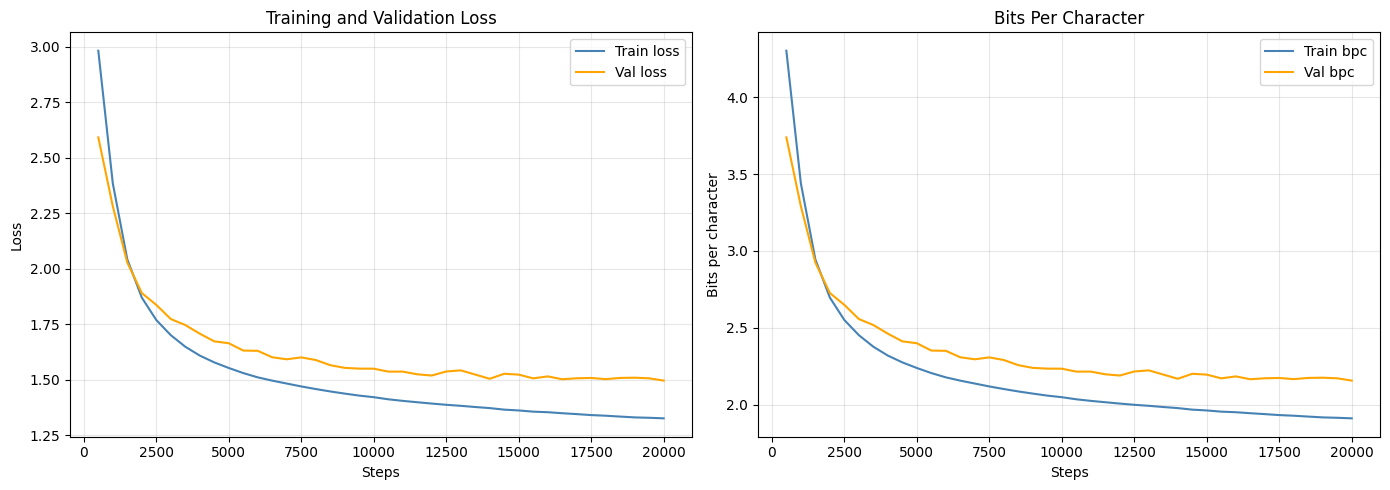

Plot saved to Drive


In [ ]:
steps_t, losses_t = zip(*train_losses)
steps_v, losses_v = zip(*val_losses)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# loss plot
ax1.plot(steps_t, losses_t, label='Train loss', color='steelblue')
ax1.plot(steps_v, losses_v, label='Val loss',   color='orange')
ax1.set_xlabel('Steps')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# bits per character plot
bpc_t = [l / math.log(2) for l in losses_t]
bpc_v = [l / math.log(2) for l in losses_v]
ax2.plot(steps_t, bpc_t, label='Train bpc', color='steelblue')
ax2.plot(steps_v, bpc_v, label='Val bpc',   color='orange')
ax2.set_xlabel('Steps')
ax2.set_ylabel('Bits per character')
ax2.set_title('Bits Per Character')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CACHE_DIR, 'learning_curves.png'), dpi=150)
plt.show()
print("Plot saved to Drive")

# CELL 10 — Hyperparameter Experiments (Stage III)

In [ ]:
def train_variant(config_override, variant_name, steps=10000):
    """
    Train a model variant with different hyperparameters.
    """
    VARIANT_CACHE = os.path.join(CACHE_DIR, f'variant_{variant_name}.pt')

    if os.path.exists(VARIANT_CACHE):
        print(f"Loading cached variant: {variant_name}")
        data = torch.load(VARIANT_CACHE, map_location=device)
        return data['train_losses'], data['val_losses']

    # merge configs
    cfg = {**CONFIG, **config_override}

    print(f"\nTraining variant: {variant_name}")
    print(f"Changes: {config_override}")

    m = CharGPT(
        vocab_size     = cfg['vocab_size'],
        embed_dim      = cfg['embed_dim'],
        num_heads      = cfg['num_heads'],
        num_layers     = cfg['num_layers'],
        context_length = cfg['context_length'],
        dropout        = cfg['dropout'],
    ).to(device)

    opt = torch.optim.AdamW(m.parameters(), lr=cfg['learning_rate'])

    t_losses, v_losses = [], []
    running = 0.0
    loader = DataLoader(
        PoetryDataset(train_data, cfg['context_length']),
        batch_size=cfg['batch_size'], shuffle=True
    )
    v_loader = DataLoader(
        PoetryDataset(val_data, cfg['context_length']),
        batch_size=cfg['batch_size'], shuffle=False
    )
    it = iter(loader)

    for step in range(steps):
        try:
            x, y = next(it)
        except StopIteration:
            it = iter(loader)
            x, y = next(it)

        x, y = x.to(device), y.to(device)
        _, loss = m(x, y)
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
        opt.step()
        running += loss.item()

        if (step + 1) % 500 == 0:
            vl = estimate_val_loss(m, v_loader)
            tl = running / 500
            t_losses.append((step + 1, tl))
            v_losses.append((step + 1, vl))
            print(f"  step {step+1}: train={tl:.4f} val={vl:.4f}")
            running = 0.0

    torch.save({'train_losses': t_losses, 'val_losses': v_losses}, VARIANT_CACHE)
    return t_losses, v_losses


# run 3 variants as the professor asks
# variant 1: fewer layers (3 instead of 6)
losses_3layers_t, losses_3layers_v = train_variant(
    {'num_layers': 3},
    'fewer_layers'
)

# variant 2: smaller model (embed_dim 128 instead of 256)
losses_small_t, losses_small_v = train_variant(
    {'embed_dim': 128, 'num_heads': 4},
    'smaller_model'
)

# variant 3: higher dropout (0.3 instead of 0.1)
losses_dropout_t, losses_dropout_v = train_variant(
    {'dropout': 0.3},
    'high_dropout'
)

Loading cached variant: fewer_layers
Loading cached variant: smaller_model
Loading cached variant: high_dropout


# CELL 11 — Plot Hyperparameter Comparison

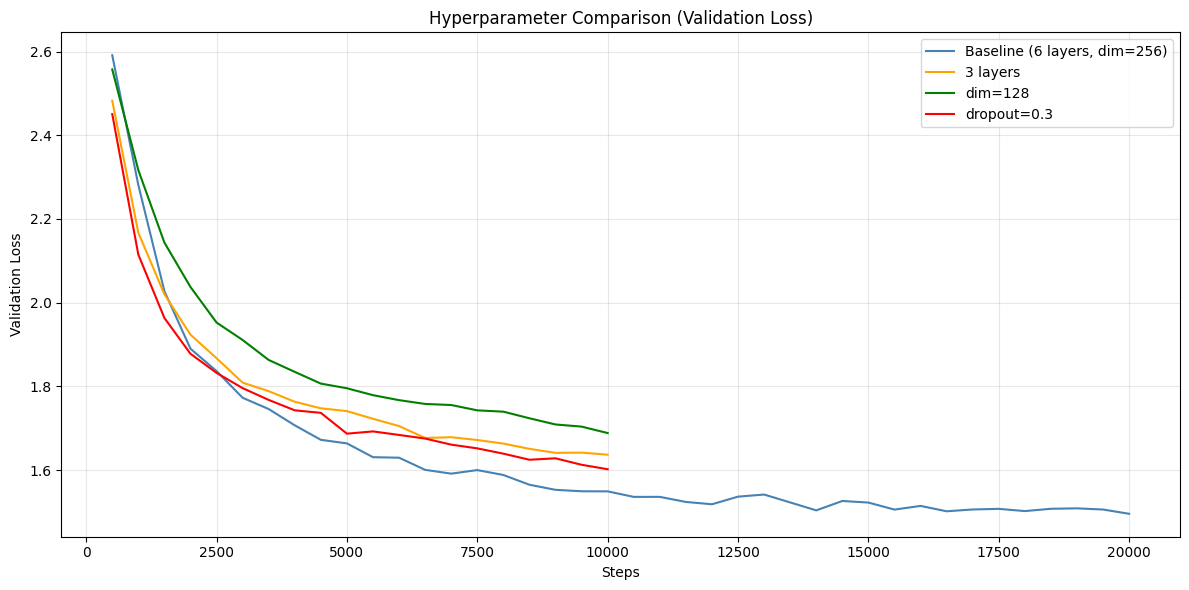

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

def plot_variant(losses, label, color, linestyle='-'):
    steps, vals = zip(*losses)
    ax.plot(steps, vals, label=label, color=color, linestyle=linestyle)

# baseline val loss
plot_variant(val_losses,         'Baseline (6 layers, dim=256)',  'steelblue')
plot_variant(losses_3layers_v,   '3 layers',                      'orange')
plot_variant(losses_small_v,     'dim=128',                       'green')
plot_variant(losses_dropout_v,   'dropout=0.3',                   'red')

ax.set_xlabel('Steps')
ax.set_ylabel('Validation Loss')
ax.set_title('Hyperparameter Comparison (Validation Loss)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CACHE_DIR, 'hyperparameter_comparison.png'), dpi=150)
plt.show()

# CELL 12 — Generate Poems (Stage IV)

In [ ]:
# load best model (baseline)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state'])
model.eval()

# generate with different temperatures
print("="*60)
print("GENERATED POEM — temperature 0.5 (conservative)")
print("="*60)
poem1 = sample_poem(model, prompt_text="\n", max_new_chars=400, temperature=0.5)
print(poem1)

print("\n" + "="*60)
print("GENERATED POEM — temperature 1.0 (balanced)")
print("="*60)
poem2 = sample_poem(model, prompt_text="\n", max_new_chars=400, temperature=1.0)
print(poem2)

print("\n" + "="*60)
print("GENERATED POEM — temperature 1.3 (creative)")
print("="*60)
poem3 = sample_poem(model, prompt_text="\n", max_new_chars=400, temperature=1.3)
print(poem3)

GENERATED POEM — temperature 0.5 (conservative)

And though the morning moon and the foe,
When the land was left the sun as she came,
And the horn was clear the sheep in the deep,
And the time was sunny and the sea,
And the silent stars she stands in the skies,
And the torrent took the stone of the place.
And the dews they pass the sky of the dead,
The cramped grass they sat and the sea;
The ship of the sounding castle came,
And the grass they s

GENERATED POEM — temperature 1.0 (balanced)

But their thighs
On caverness at the four-frailted heads;--
"Wink at the banks of hope, and in the night!
Now then. Now, rose! raise at once sense adore called--
Rose, therefore called and milled,
Now could turn the dial hair if the Trojan wall;
Now with the Chiefs have the sea, from ruler lock,
To rest the skies of God alarm deserved.
In votive now they would prove them, energy."
Thus again, wher

GENERATED POEM — temperature 1.3 (creative)

your yown; Jukelier Lord
That Ida dyed for ignother's gui

# CELL 13 — Structural Analysis (Stage IV)


--- Structure Analysis: Training Corpus (sample) ---
Total lines: 1175
Avg line length: 41.6 chars (std: 6.8)
Line length range: 3–60
Number of stanzas: 2
Avg stanza length: 587.5 lines
Most common line endings: [('e,', 106), ('s,', 85), ('d,', 79), ('e.', 65), ('t,', 48)]

--- Structure Analysis: Generated (temp=0.5) ---
Total lines: 10
Avg line length: 39.1 chars (std: 7.1)
Line length range: 20–45
Number of stanzas: 1
Avg stanza length: 10.0 lines
Most common line endings: [('e,', 3), ('p,', 1), ('a,', 1), ('s,', 1), ('e.', 1)]

--- Structure Analysis: Generated (temp=1.0) ---
Total lines: 10
Avg line length: 39.1 chars (std: 12.7)
Line length range: 16–55
Number of stanzas: 1
Avg stanza length: 10.0 lines
Most common line endings: [('--', 2), ('hs', 1), ('t!', 1), ('d,', 1), ('l;', 1)]

--- Structure Analysis: Generated (temp=1.3) ---
Total lines: 10
Avg line length: 39.1 chars (std: 7.2)
Line length range: 24–49
Number of stanzas: 1
Avg stanza length: 10.0 lines
Most common line 

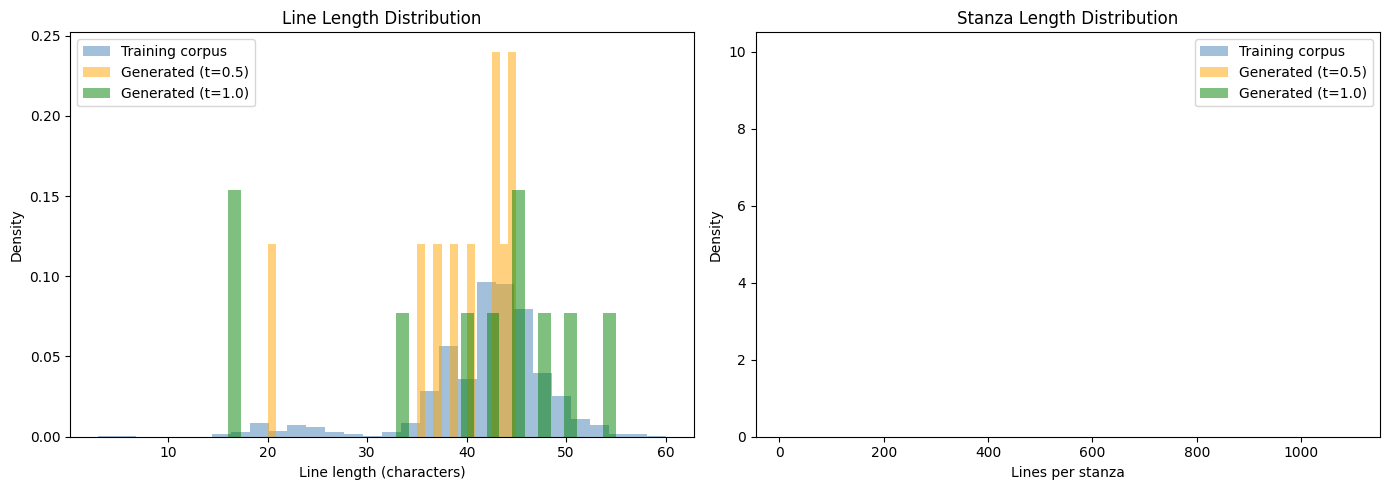

Analysis plot saved to Drive


In [ ]:
def analyze_poem_structure(text, label=""):
    """
    Analyze structural properties of generated poems:
    - line lengths distribution
    - stanza lengths
    - basic rhyme detection (last word of each line)
    """
    lines = text.split('\n')
    lines = [l for l in lines if l.strip()]  # remove empty lines

    # line lengths
    line_lengths = [len(l) for l in lines]

    # stanza detection: groups of lines separated by blank lines
    stanzas = text.split('\n\n')
    stanza_lengths = [len([l for l in s.split('\n') if l.strip()])
                      for s in stanzas if s.strip()]

    # simple rhyme detection: last 2 characters of each line
    # real rhyme detection is complex so we use this as approximation
    endings = [l.strip()[-2:].lower() if len(l.strip()) >= 2
               else '' for l in lines]
    ending_counts = Counter(endings)
    most_common_endings = ending_counts.most_common(5)

    print(f"\n--- Structure Analysis: {label} ---")
    print(f"Total lines: {len(lines)}")
    print(f"Avg line length: {np.mean(line_lengths):.1f} chars "
          f"(std: {np.std(line_lengths):.1f})")
    print(f"Line length range: {min(line_lengths)}–{max(line_lengths)}")
    print(f"Number of stanzas: {len(stanza_lengths)}")
    print(f"Avg stanza length: {np.mean(stanza_lengths):.1f} lines")
    print(f"Most common line endings: {most_common_endings}")

    return line_lengths, stanza_lengths


# analyze training corpus for comparison
corpus_line_lengths, corpus_stanza_lengths = analyze_poem_structure(
    corpus_text[:50000], label="Training Corpus (sample)"
)

# analyze generated poems
gen_line_lengths1, gen_stanza_lengths1 = analyze_poem_structure(
    poem1, label="Generated (temp=0.5)"
)
gen_line_lengths2, gen_stanza_lengths2 = analyze_poem_structure(
    poem2, label="Generated (temp=1.0)"
)
gen_line_lengths3, gen_stanza_lengths3 = analyze_poem_structure(
    poem3, label="Generated (temp=1.3)"
)

# plot line length distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# line lengths
axes[0].hist(corpus_line_lengths, bins=30, alpha=0.5,
             label='Training corpus', color='steelblue', density=True)
axes[0].hist(gen_line_lengths1,    bins=30, alpha=0.5,
             label='Generated (t=0.5)', color='orange', density=True)
axes[0].hist(gen_line_lengths2,    bins=30, alpha=0.5,
             label='Generated (t=1.0)', color='green', density=True)
axes[0].set_xlabel('Line length (characters)')
axes[0].set_ylabel('Density')
axes[0].set_title('Line Length Distribution')
axes[0].legend()

# stanza lengths
axes[1].hist(corpus_stanza_lengths, bins=10, alpha=0.5,
             label='Training corpus', color='steelblue', density=True)
axes[1].hist(gen_stanza_lengths1,   bins=10, alpha=0.5,
             label='Generated (t=0.5)', color='orange', density=True)
axes[1].hist(gen_stanza_lengths2,   bins=10, alpha=0.5,
             label='Generated (t=1.0)', color='green', density=True)
axes[1].set_xlabel('Lines per stanza')
axes[1].set_ylabel('Density')
axes[1].set_title('Stanza Length Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(CACHE_DIR, 'structural_analysis.png'), dpi=150)
plt.show()
print("Analysis plot saved to Drive")